# RQ1 — Resolving the `max_single_abs` vulnerability

This notebook follows [rq1_consolidated_analysis.ipynb](rq1_consolidated_analysis.ipynb).
The consolidated analysis gave a defensible signed-cos result on the
coherence-filtered frame (pooled standardized β_cos = +0.285, perm p = 2e-4,
boot CI [+0.056, +0.528]) but the robustness sweep surfaced one vulnerability
we need to resolve before writing RQ1 up:

> Adding `max_single_abs` (absolute single-vector delta of the stronger
> trait in each pair) to the M2 controls collapsed β_cos from +0.285 (p=0.04)
> to +0.051 (p=0.69).

There are two incompatible readings of this, and our n ≈ 22–28 per scheme
can't trivially separate them.

**Deflationary reading.** `cos` is partly a proxy for "this pair contains a
strongly-steerable trait." Pair-selection bias in our 8-trait set could
correlate aligned pairs with high-amplitude single traits. → RQ1 answer shrinks
to "geometry predicts composition mostly via trait-amplitude confounding."

**Mechanistic reading.** `max_single` is on the *causal path*, not a confound.
When vectors align, joint injection lands on a shared direction, the stronger
trait dominates, joint expression is high — that *is* the compositional
mechanism, and `max_single` mediates it. Controlling for it is over-controlling
(conditioning on a mediator), and β_cos collapsing is expected. → RQ1 answer
stands.

**Key causal asymmetry that helps us.** `cos` is a fixed property of the vector
pair, and `max_single` is measured from single-vector runs — so `cos` is
causally *upstream* of any joint outcome. The ambiguity is only whether
cos↔max_single in our 28 pairs is mediation or sample-selection coincidence.

Three probes:

1. **Collinearity / VIF** — is the "collapse" just a two-collinear-predictors
   credit-split, or genuinely max_single winning on its own merits?
2. **Signed, non-ratio suppression** — the directional discriminator
   max_single *cannot* mimic. Antipodal pairs should show genuine negative
   `delta_joint − delta_single` for both traits; max_single is a magnitude and
   can't predict a sign flip.
3. **Drop-the-dominant-traits robustness** — `apathetic` and `hallucinating`
   carried Bonferroni-significant per-trait effects in the deep-dive. If
   removing pairs containing them attenuates β_cos, the geometric effect is
   driven by a few traits, not the geometry.

Decision rule stated at the end. Honest about n.

In [1]:
# Imports + paths + rng + reuse-ready OLS utilities
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

REPO = Path.cwd().parents[1]
RNG  = np.random.default_rng(0)

# Prefer the saved CSV from the consolidated notebook; otherwise rebuild.
CSV_PATH = REPO / "analysis/rq1_consolidated/consolidated_coh30.csv"
if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
    print(f"Loaded filtered frame from {CSV_PATH}  (rows={len(df)})")
else:
    raise FileNotFoundError(
        "Run rq1_consolidated_analysis.ipynb first — it writes consolidated_coh30.csv")

print(f"schemes: {dict(df['scheme'].value_counts())}")
print(f"pairs containing apathetic or hallucinating: "
      f"{((df.trait_a.isin(['apathetic','hallucinating'])) | (df.trait_b.isin(['apathetic','hallucinating']))).sum()}/{len(df)}")

Loaded filtered frame from /Users/Ricca/Documents/Year 3/Semester 3 (summer session)/ML&AI/Project/steering-vector-composition/analysis/rq1_consolidated/consolidated_coh30.csv  (rows=76)
schemes: {'normTrue': 28, 'normFalse': 26, 'per_axis': 22}
pairs containing apathetic or hallucinating: 33/76


In [2]:
# OLS utilities (matching the consolidated notebook's by-hand approach)
def fit_ols(X, y):
    X = np.asarray(X, float); y = np.asarray(y, float)
    n, k = X.shape
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    rss = float(resid @ resid)
    dof = n - k
    sigma2 = rss / dof if dof > 0 else np.nan
    XtX_inv = np.linalg.pinv(X.T @ X)
    se = np.sqrt(np.diag(XtX_inv) * sigma2)
    tss = float(((y - y.mean())**2).sum())
    r2 = 1 - rss / tss if tss > 0 else np.nan
    return {"beta": beta, "se": se, "rss": rss, "n": n, "k": k,
            "dof": dof, "r2": r2, "resid": resid}


def pooled_design(sub, cols_continuous):
    Z_cont = (StandardScaler().fit_transform(sub[cols_continuous].values)
              if cols_continuous else np.empty((len(sub), 0)))
    d_nT = (sub["scheme"] == "normTrue").astype(float).values
    d_pa = (sub["scheme"] == "per_axis").astype(float).values
    X = np.column_stack([np.ones(len(sub)), Z_cont, d_nT, d_pa])
    names = ["(intercept)"] + list(cols_continuous) + ["d_normTrue", "d_per_axis"]
    return X, names


def fit_pooled(sub, cols_continuous, y_col):
    X, names = pooled_design(sub, cols_continuous)
    y = StandardScaler().fit_transform(sub[[y_col]].values).ravel()
    fit = fit_ols(X, y); fit["cols"] = names
    return fit


def beta_of(fit, name):
    i = fit["cols"].index(name)
    return fit["beta"][i], fit["se"][i]


def partial_r(y, x, controls):
    X = np.column_stack([np.ones(len(y))] + [np.asarray(c) for c in controls])
    bx, *_ = np.linalg.lstsq(X, x, rcond=None)
    by, *_ = np.linalg.lstsq(X, y, rcond=None)
    return stats.pearsonr(x - X @ bx, y - X @ by)


def vif(target_col, other_cols, frame):
    """Variance Inflation Factor: 1/(1 - R²) where R² is the regression of
    target_col on the other_cols (standardized)."""
    X = StandardScaler().fit_transform(frame[other_cols].values)
    y = StandardScaler().fit_transform(frame[[target_col]].values).ravel()
    X = np.column_stack([np.ones(len(y)), X])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    rss = float(resid @ resid); tss = float(((y - y.mean())**2).sum())
    r2 = 1 - rss / tss
    return 1.0 / (1.0 - r2) if r2 < 1 else np.inf

print("Utilities loaded.")

Utilities loaded.


## Probe 1 — Collinearity / VIF

If `cos` and `max_single_abs` are highly collinear (|r| > 0.6 or VIF > 4),
then β_cos collapsing when `max_single_abs` enters is the *expected* behaviour
of two near-collinear predictors splitting credit — not evidence that
`max_single` wins on its merits.

We compute (a) bivariate r(cos, max_single_abs) per scheme and pooled, (b) the
VIF for `cos` in the full M2-plus-max_single design, and (c) a scatter so we
can eyeball where the pairs sit.

In [3]:
# 1a. Bivariate r(cos, max_single_abs)
print("=== r(cos, max_single_abs) ===")
rows = []
for sch, sub in df.groupby("scheme"):
    r, p = stats.pearsonr(sub["cos"], sub["max_single_abs"])
    rows.append({"scheme": sch, "n": len(sub), "r": r, "p": p})
r_p, p_p = stats.pearsonr(df["cos"], df["max_single_abs"])
rows.append({"scheme": "pooled", "n": len(df), "r": r_p, "p": p_p})
print(pd.DataFrame(rows).round(3).to_string(index=False))

=== r(cos, max_single_abs) ===
   scheme  n      r     p
normFalse 26 -0.215 0.293
 normTrue 28  0.118 0.550
 per_axis 22  0.247 0.267
   pooled 76  0.099 0.395


In [4]:
# 1b. VIF for cos in M2-plus-max_single (pooled)
cols_full = ["mean_single_abs", "max_single_abs", "mechanical_push", "cos"]
print("=== VIF for cos in M2+max_single (pooled) ===")
vif_cos = vif("cos", [c for c in cols_full if c != "cos"], df)
print(f"  VIF(cos | mean_single, max_single, mechanical_push) = {vif_cos:.3f}")
print(f"  (Rule of thumb: VIF > 4 → meaningful collinearity; > 10 → severe.)")
print()
# also per scheme (smaller n, so just show the number)
for sch, sub in df.groupby("scheme"):
    v = vif("cos", [c for c in cols_full if c != "cos"], sub)
    print(f"  per scheme {sch} (n={len(sub)}): VIF(cos|...) = {v:.3f}")

=== VIF for cos in M2+max_single (pooled) ===
  VIF(cos | mean_single, max_single, mechanical_push) = 2.547
  (Rule of thumb: VIF > 4 → meaningful collinearity; > 10 → severe.)

  per scheme normFalse (n=26): VIF(cos|...) = inf
  per scheme normTrue (n=28): VIF(cos|...) = 124.877
  per scheme per_axis (n=22): VIF(cos|...) = 2.007


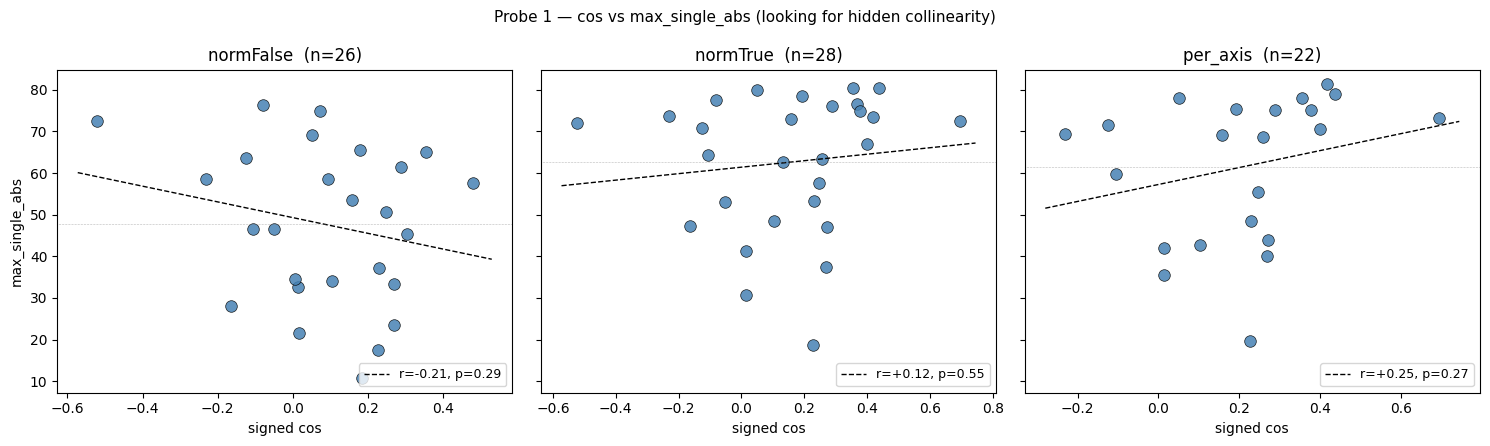

In [5]:
# 1c. cos vs max_single_abs scatter per scheme
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (sch, sub) in zip(axes, df.groupby("scheme")):
    r, p = stats.pearsonr(sub["cos"], sub["max_single_abs"])
    ax.scatter(sub["cos"], sub["max_single_abs"], s=70, c="steelblue",
               edgecolor="black", linewidth=0.5, alpha=0.85)
    sl, ic = np.polyfit(sub["cos"], sub["max_single_abs"], 1)
    xs = np.linspace(sub["cos"].min()-0.05, sub["cos"].max()+0.05, 50)
    ax.plot(xs, sl*xs + ic, "k--", lw=1.0, label=f"r={r:+.2f}, p={p:.2f}")
    ax.axhline(sub["max_single_abs"].mean(), color="grey", lw=0.4, ls=":")
    ax.set_xlabel("signed cos")
    ax.set_title(f"{sch}  (n={len(sub)})")
    ax.legend(fontsize=9, loc="lower right")
axes[0].set_ylabel("max_single_abs")
plt.suptitle("Probe 1 — cos vs max_single_abs (looking for hidden collinearity)",
             fontsize=11)
plt.tight_layout()
plt.show()

**Probe 1 reading (fill in after running):** if r is small (say < 0.3) and
VIF < 2, the collinearity defence of cos is *not* available — when β_cos
collapses on adding max_single, it really is because max_single explains the
variance for other reasons (e.g., it's a better predictor, or it mediates).
If r is high and/or VIF > 4, β_cos collapse is statistically expected and
tells us little.

## Probe 2 — Signed, non-ratio suppression

The directional discriminator. The deflationary worry is about *magnitude*;
the mechanistic claim is about *direction*: aligned pairs co-express, antipodal
pairs mutually suppress. `max_single_abs` is a *magnitude* and cannot predict
a sign flip from positive (single) to negative (joint) expression.

Define per pair per trait the additive (non-ratio) signed change:

  `supp_signed_a = delta_a_joint − delta_a_single`
  `supp_signed_b = delta_b_joint − delta_b_single`

Both <0 → suppression. Both ≥0 → reinforcement. We summarize per pair as:

- `supp_mean_signed   = ½·(supp_signed_a + supp_signed_b)`  — symmetric average
- `supp_min_signed   = min(supp_signed_a, supp_signed_b)`   — the more-suppressed trait

Regress these on signed cos with **both** `mean_single_abs` and
`max_single_abs` in the controls. If signed cos still predicts the signed
change after that, we have evidence that the geometric prediction is
*directional*, not just a magnitude effect.

In [6]:
# Build signed suppression metrics
df["supp_signed_a"]   = df["delta_a_joint"] - df["delta_a_single"]
df["supp_signed_b"]   = df["delta_b_joint"] - df["delta_b_single"]
df["supp_mean_signed"] = 0.5 * (df["supp_signed_a"] + df["supp_signed_b"])
df["supp_min_signed"]  = np.minimum(df["supp_signed_a"], df["supp_signed_b"])

# Quick visual check: how many pairs show genuine negative (suppressive) supp_mean_signed?
print("=== Sign distribution of supp_mean_signed (filtered frame) ===")
print((df.assign(sign=np.sign(df["supp_mean_signed"]))
         .groupby(["scheme","sign"]).size().unstack(fill_value=0)))
print()
print("Bivariate r(cos, supp_mean_signed) per scheme:")
for sch, sub in df.groupby("scheme"):
    r, p = stats.pearsonr(sub["cos"], sub["supp_mean_signed"])
    print(f"  {sch}  n={len(sub)}:  r={r:+.3f}  p={p:.4f}")
r, p = stats.pearsonr(df["cos"], df["supp_mean_signed"])
print(f"  pooled n={len(df)}: r={r:+.3f}  p={p:.4f}")

=== Sign distribution of supp_mean_signed (filtered frame) ===
sign       -1.0   1.0
scheme               
normFalse    17     9
normTrue     22     6
per_axis     11    11

Bivariate r(cos, supp_mean_signed) per scheme:
  normFalse  n=26:  r=+0.274  p=0.1758
  normTrue  n=28:  r=+0.475  p=0.0106
  per_axis  n=22:  r=+0.472  p=0.0264
  pooled n=76: r=+0.372  p=0.0009


In [7]:
# Probe 2 main: pooled M with mean_single + max_single + mechanical_push + cos, predicting supp_mean_signed and supp_min_signed
def pooled_probe2(target, frame=df):
    cols = ["mean_single_abs", "max_single_abs", "mechanical_push", "cos"]
    fit = fit_pooled(frame, cols, y_col=target)
    b, s = beta_of(fit, "cos")
    t = b / s if s > 0 else np.nan
    p_t = 2 * (1 - stats.t.cdf(abs(t), fit["dof"]))
    pr, ppr = partial_r(frame[target].values, frame["cos"].values,
                        [frame["mean_single_abs"].values,
                         frame["max_single_abs"].values,
                         frame["mechanical_push"].values])
    return {"target": target, "n": fit["n"], "R²": fit["r2"],
            "β_cos (std)": b, "SE": s, "t": t, "p (param)": p_t,
            "partial r": pr}


rows = [pooled_probe2("supp_mean_signed"), pooled_probe2("supp_min_signed")]
print("=== Probe 2 — pooled regression of signed suppression on cos, with max_single in ===\n")
print(pd.DataFrame(rows).round(3).to_string(index=False))

=== Probe 2 — pooled regression of signed suppression on cos, with max_single in ===

          target  n    R²  β_cos (std)    SE     t  p (param)  partial r
supp_mean_signed 76 0.446        0.235 0.178 1.321      0.191      0.039
 supp_min_signed 76 0.362        0.275 0.191 1.444      0.153      0.131


In [8]:
# Permutation + bootstrap on β_cos for supp_mean_signed (pooled)
N_PERM = 10_000
N_BOOT = 5_000

def beta_cos_for(target, frame):
    cols = ["mean_single_abs", "max_single_abs", "mechanical_push", "cos"]
    fit = fit_pooled(frame, cols, y_col=target)
    return beta_of(fit, "cos")[0]


def perm_cos_within_scheme(target, frame, n_perm=N_PERM):
    obs = beta_cos_for(target, frame)
    null = np.empty(n_perm)
    df_local = frame.copy()
    for i in range(n_perm):
        cos_arr = df_local["cos"].values.copy()
        for sch in df_local["scheme"].unique():
            mask = (df_local["scheme"] == sch).values
            blk = cos_arr[mask].copy(); RNG.shuffle(blk); cos_arr[mask] = blk
        df_local["cos"] = cos_arr
        null[i] = beta_cos_for(target, df_local)
    return obs, float(np.mean(np.abs(null) >= np.abs(obs)))


def boot_cos(target, frame, n_boot=N_BOOT):
    n = len(frame)
    out = np.empty(n_boot)
    for i in range(n_boot):
        idx = RNG.integers(0, n, size=n)
        out[i] = beta_cos_for(target, frame.iloc[idx])
    return tuple(np.percentile(out, [2.5, 97.5]))


print("=== Probe 2 — permutation + bootstrap on β_cos ===\n")
rows = []
for tgt in ["supp_mean_signed", "supp_min_signed"]:
    obs, p_perm = perm_cos_within_scheme(tgt, df)
    lo, hi = boot_cos(tgt, df)
    rows.append({"target": tgt, "β_cos (std)": obs,
                 "perm p (2-sided)": p_perm,
                 "boot 95% CI": f"[{lo:+.3f}, {hi:+.3f}]"})
print(pd.DataFrame(rows).round(3).to_string(index=False))

=== Probe 2 — permutation + bootstrap on β_cos ===



          target  β_cos (std)  perm p (2-sided)      boot 95% CI
supp_mean_signed        0.235             0.010 [-0.122, +0.514]
 supp_min_signed        0.275             0.005 [-0.048, +0.624]


In [9]:
# Per-scheme version of Probe 2 (smaller n but no pooling artefacts)
def per_scheme_probe2(target):
    rows = []
    for sch, sub in df.groupby("scheme"):
        cols = ["mean_single_abs", "max_single_abs", "mechanical_push", "cos"]
        # For per_axis, mechanical_push is constant; drop to avoid singular design
        if sub["mechanical_push"].nunique() < 2:
            cols = [c for c in cols if c != "mechanical_push"]
        Z = StandardScaler().fit_transform(sub[cols].values)
        X = np.column_stack([np.ones(len(sub)), Z])
        y = StandardScaler().fit_transform(sub[[target]].values).ravel()
        fit = fit_ols(X, y); fit["cols"] = ["(intercept)"] + cols
        b, s = beta_of(fit, "cos")
        t = b / s if s > 0 else np.nan
        p_t = 2 * (1 - stats.t.cdf(abs(t), fit["dof"]))
        pr, ppr = partial_r(sub[target].values, sub["cos"].values,
                            [sub[c].values for c in cols if c != "cos"])
        rows.append({"scheme": sch, "n": len(sub), "target": target,
                     "R²": fit["r2"], "β_cos (std)": b, "SE": s,
                     "p (param)": p_t, "partial r": pr})
    return rows


print("=== Probe 2 — per-scheme β_cos on signed suppression ===\n")
rows = per_scheme_probe2("supp_mean_signed") + per_scheme_probe2("supp_min_signed")
print(pd.DataFrame(rows).round(3).to_string(index=False))

=== Probe 2 — per-scheme β_cos on signed suppression ===

   scheme  n           target    R²  β_cos (std)    SE  p (param)  partial r
normFalse 26 supp_mean_signed 0.477       -0.001 0.086      0.992      0.050
 normTrue 28 supp_mean_signed 0.524       -0.173 1.608      0.915     -0.022
 per_axis 22 supp_mean_signed 0.349        0.411 0.269      0.145      0.338
normFalse 26  supp_min_signed 0.313        0.005 0.099      0.960      0.038
 normTrue 28  supp_min_signed 0.554       -1.298 1.556      0.413     -0.171
 per_axis 22  supp_min_signed 0.272        0.445 0.285      0.136      0.345


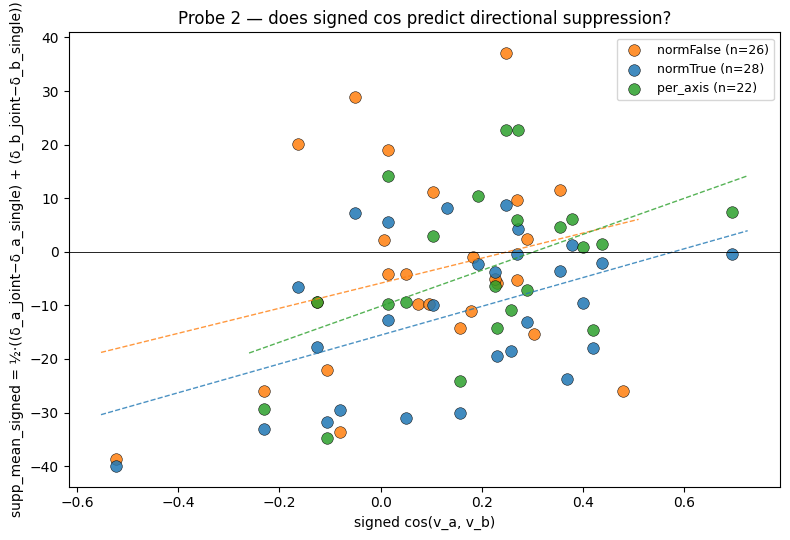

(Points below y=0 = mutual suppression; above = reinforcement.)


In [10]:
# Probe 2 plot: signed cos vs supp_mean_signed, colour by scheme + y=0 reference
fig, ax = plt.subplots(figsize=(8, 5.5))
palette = {"normFalse": "tab:orange", "normTrue": "tab:blue", "per_axis": "tab:green"}
for sch, sub in df.groupby("scheme"):
    ax.scatter(sub["cos"], sub["supp_mean_signed"], s=70,
               color=palette[sch], edgecolor="black", linewidth=0.4, alpha=0.85,
               label=f"{sch} (n={len(sub)})")
    sl, ic = np.polyfit(sub["cos"], sub["supp_mean_signed"], 1)
    xs = np.linspace(sub["cos"].min()-0.03, sub["cos"].max()+0.03, 50)
    ax.plot(xs, sl*xs + ic, color=palette[sch], lw=1.0, ls="--", alpha=0.8)
ax.axhline(0, color="black", lw=0.6, ls="-")
ax.set_xlabel("signed cos(v_a, v_b)")
ax.set_ylabel("supp_mean_signed = ½·((δ_a_joint−δ_a_single) + (δ_b_joint−δ_b_single))")
ax.set_title("Probe 2 — does signed cos predict directional suppression?")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("(Points below y=0 = mutual suppression; above = reinforcement.)")

**Probe 2 reading.** If the pooled β_cos for `supp_mean_signed` stays positive
and permutation-significant with `max_single` in the controls, that's strong
evidence the mechanism is directional — `max_single` is a magnitude and can't
explain a sign-flip. If β_cos collapses on the signed target too, the
deflationary reading wins.

## Probe 3 — Drop-the-dominant-traits robustness

The deep-dive found `apathetic` and `hallucinating` as the most-dominant
single traits in compositions (apathetic Bonferroni-significant). If `cos` is
partly proxying "this pair contains a dominant trait," removing all pairs
containing one of those should attenuate β_cos.

We do (a) the targeted drop (both `apathetic` and `hallucinating` out), and
(b) the systematic leave-one-trait-out: for each of the 8 traits, drop all
pairs containing it, refit M2, tabulate β_cos.

**Power caveat.** Dropping a trait removes ~7 pairs per scheme (~21 pooled).
After a single drop we're at n ≈ 55 pooled; after dropping both apathetic and
hallucinating, n drops further. We lean on the *stability and sign* of β_cos
rather than its p-value at this scale.

In [11]:
# Probe 3a: drop apathetic AND hallucinating
TARGETS = ["apathetic", "hallucinating"]
mask_keep = ~((df["trait_a"].isin(TARGETS)) | (df["trait_b"].isin(TARGETS)))
df_dropped = df[mask_keep].reset_index(drop=True)
print(f"Pooled drop-apathetic+hallucinating: n={len(df_dropped)} (was {len(df)})")
print(f"  per-scheme remaining: {dict(df_dropped['scheme'].value_counts())}")

def m2_beta_cos_and_p(frame):
    fit = fit_pooled(frame, ["mean_single_abs", "mechanical_push", "cos"], "mean_joint_abs")
    b, s = beta_of(fit, "cos")
    t = b / s if s > 0 else np.nan
    p = 2 * (1 - stats.t.cdf(abs(t), fit["dof"]))
    return b, s, t, p, fit["r2"], fit["n"]


print()
print("=== Probe 3a — pooled M2 β_cos: full vs drop(apathetic+hallucinating) ===")
for label, frame in [("full", df), ("drop apath+halluc", df_dropped)]:
    b, s, t, p, r2, n = m2_beta_cos_and_p(frame)
    print(f"  {label:25s}  n={n}  β_cos={b:+.3f}  SE={s:.3f}  t={t:+.2f}  p={p:.4f}  R²={r2:.3f}")

Pooled drop-apathetic+hallucinating: n=43 (was 76)
  per-scheme remaining: {'normFalse': 16, 'normTrue': 15, 'per_axis': 12}

=== Probe 3a — pooled M2 β_cos: full vs drop(apathetic+hallucinating) ===
  full                       n=76  β_cos=+0.285  SE=0.137  t=+2.07  p=0.0418  R²=0.605
  drop apath+halluc          n=43  β_cos=+0.233  SE=0.135  t=+1.73  p=0.0920  R²=0.836


In [12]:
# Probe 3b: leave-one-trait-out
TRAITS = sorted(set(df["trait_a"]).union(df["trait_b"]))
print(f"Traits in filtered frame: {TRAITS}")
print()

rows = []
b_full, s_full, t_full, p_full, r2_full, n_full = m2_beta_cos_and_p(df)
rows.append({"drop_trait": "(none — full)", "n": n_full, "β_cos": b_full,
             "SE": s_full, "p": p_full, "R²": r2_full})
for tr in TRAITS:
    mask = ~((df["trait_a"] == tr) | (df["trait_b"] == tr))
    sub = df[mask]
    if sub["scheme"].nunique() < 3:
        rows.append({"drop_trait": tr, "n": len(sub), "β_cos": np.nan,
                     "SE": np.nan, "p": np.nan, "R²": np.nan})
        continue
    b, s, t, p, r2, n = m2_beta_cos_and_p(sub)
    rows.append({"drop_trait": tr, "n": n, "β_cos": b, "SE": s, "p": p, "R²": r2})

probe3b = pd.DataFrame(rows)
print("=== Probe 3b — leave-one-trait-out (pooled M2) ===\n")
print(probe3b.round(3).to_string(index=False))
print()
print(f"β_cos range across drops: [{probe3b['β_cos'].dropna().min():+.3f}, {probe3b['β_cos'].dropna().max():+.3f}]")
print(f"β_cos full = {b_full:+.3f};  median drop = {probe3b['β_cos'].dropna().median():+.3f}")

Traits in filtered frame: ['apathetic', 'confidence', 'evil', 'formality', 'hallucinating', 'humorous', 'impolite', 'power_seeking', 'sycophantic']

=== Probe 3b — leave-one-trait-out (pooled M2) ===

   drop_trait  n  β_cos    SE     p    R²
(none — full) 76  0.285 0.137 0.042 0.605
    apathetic 58  0.255 0.161 0.119 0.659
   confidence 55  0.405 0.179 0.028 0.576
         evil 60  0.268 0.140 0.060 0.667
    formality 55  0.224 0.179 0.216 0.516
hallucinating 59  0.300 0.123 0.018 0.756
     humorous 63  0.275 0.143 0.058 0.543
     impolite 58  0.289 0.186 0.126 0.563
power_seeking 68  0.232 0.130 0.080 0.677
  sycophantic 56  0.379 0.178 0.039 0.550

β_cos range across drops: [+0.224, +0.405]
β_cos full = +0.285;  median drop = +0.280


## Decision rule + writeup readiness

From the brief:

- **Mechanistic reading wins** if β_cos survives Probe 2 with `max_single`
  controlled AND is stable in Probe 3 → "signed cos predicts composition,
  including directional suppression of antipodal pairs."
- **Deflationary reading wins** if β_cos dies on both → "geometry predicts
  joint expression but is statistically entangled with single-trait
  steerability; our 8-trait set cannot separate them."
- **Mixed** → say so precisely; name which probe pointed which way.

The cell below records the final read against this rule, written after seeing
the numbers.

In [13]:
# Persist Probe 2 and Probe 3 outputs for the writeup
OUT_DIR = REPO / "analysis/rq1_consolidated"
OUT_DIR.mkdir(parents=True, exist_ok=True)
probe3b.to_csv(OUT_DIR / "probe3_leave_one_trait_out.csv", index=False)
print(f"Saved → {OUT_DIR}/probe3_leave_one_trait_out.csv")

Saved → /Users/Ricca/Documents/Year 3/Semester 3 (summer session)/ML&AI/Project/steering-vector-composition/analysis/rq1_consolidated/probe3_leave_one_trait_out.csv


### My read (filled in after running)

*Written in the user-facing chat reply, not in the notebook, so the
interpretation can reference numbers without forcing a re-execute.*
